# Desafio Ciência e Governança de Dados

Desenvolvido por Estevão Augusto da Fonseca Santos, Graduando em Ciência de Computação

6° Período da Universidade Federal de Lavras

## Objetivos

Tendo finalizado a seção de análise exploratória. Agora, é preciso desenvolver e testar um modelo de predição, a fim de checar a correlação de dados, e sua influência em Lavras.

In [ ]:
import pandas as pd                                     # Manipulação e análise de dados em estruturas como DataFrames
import matplotlib.pyplot as plt                         # Criação de gráficos 2D de forma flexível
import seaborn as sns                                   # Visualização de dados estatísticos com gráficos mais estilizados
from sklearn.model_selection import train_test_split    # Permite dividir o dataset entre dados de treino e teste
from sklearn.linear_model import LinearRegression       # Criação de modelos de regressão linear
from sklearn.preprocessing import StandardScaler        # Padronização e normalização de dados
from sklearn.metrics import r2_score                    # Avaliação de desempenho de modelos com R²
import pickle                                           # Salvar modelos de IA no computador
import os                                               # Interação com o sistema de arquivos e funcionalidades do sistema operacional

In [ ]:
import sys
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))  # Adiciona raiz

# Define constantes que armazenam os caminhos que serão utilizados neste notebook
from config_path import RAW_DATA_DIRECTORY_PATH, PROCESSED_DATA_DIRECTORY_PATH, REPORTS_DIRECTORY_PATH, METRICS_DIRECTORY_PATH, MODEL_DIRECTORY_PATH

In [ ]:
if not os.path.isdir(REPORTS_DIRECTORY_PATH):
    os.mkdir(REPORTS_DIRECTORY_PATH)

if not os.path.isdir(MODEL_DIRECTORY_PATH):
    os.mkdir(MODEL_DIRECTORY_PATH)
    
if not os.path.isdir(METRICS_DIRECTORY_PATH):
    os.mkdir(METRICS_DIRECTORY_PATH)

In [8]:
df_municipios = pd.read_csv(f"{PROCESSED_DATA_DIRECTORY_PATH}/tamanho_populacional_mun.csv")
df_alfabetizacao = pd.read_csv(f"{PROCESSED_DATA_DIRECTORY_PATH}/alfabetizacao_processada.csv")
df_educacao = pd.read_csv(f"{RAW_DATA_DIRECTORY_PATH}/educacao_basica_sexo_raca_cor.csv")
# df_pib_mun = pd.read_csv(f"{RAW_DATA_DIRECTORY_PATH}/pip_por_municipio_original.csv")

In [14]:
# Selecionar apenas as colunas relevantes de cada DataFrame
# df_pib_mun = df_pib_mun[['id_municipio','pib','valor_adicionado_precos_correntes_total']]  # PIB e Valor Adicionado por município
df_alfabetizacao = df_alfabetizacao[['id_municipio','nome_municipio','total_alfabetizados']]  # Total de alfabetizados por município
# df_municipios = df_municipios[['id_municipio','id_municipio_nome','populacao_total','NM_UF_SIGLA','NM_UF','AR_MUN_2024','ano']]  # Informações gerais dos municípios
df_matriculas = df_educacao.groupby(['ano','id_municipio','id_municipio_nome'])['quantidade_matricula'].sum().reset_index()  # Soma das matrículas por município

# Merge sequencial dos DataFrames, combinando informações pelos IDs dos municípios
df = df_municipios.merge(df_alfabetizacao, on=['id_municipio'], how='inner')  # Adiciona dados de alfabetização
df = df.merge(df_matriculas, on=['id_municipio','ano'], how='inner')  # Adiciona dados de matrículas
df.rename(columns={ 'id_municipio_nome_x' : 'id_municipio_nome'}, inplace=True)
df.drop('id_municipio_nome_y', axis=1, inplace=True)
# df = df.merge(df_pib_mun, on='id_municipio', how='inner')  # Adiciona dados de PIB


In [15]:
df

,id_municipio,ano,populacao_total,id_municipio_nome,pib,impostos_liquidos,valor_adicionado_precos_correntes_total,valor_adicionado_correntes_agropecuaria,valor_adicionado_correntes_industria,valor_adicionado_correntes_servicos,valor_adicionado_correntes_adm_defesa_edu_saude_seguranca_social,NM_UF,NM_UF_SIGLA,CD_MUN,AR_MUN_2024,nome_municipio,total_alfabetizados,quantidade_matricula
0,1100015,2016,23614,Alta Floresta D'Oeste,478217000,23202000,455014000,166143000,31598000,114541000,142733000,Rondônia,RO,1100015.0,7067.127,Alta Floresta D'Oeste (RO),15448,6220
1,1100015,2017,23392,Alta Floresta D'Oeste,485374000,25125000,460249000,169623000,27342000,108357000,154926000,Rondônia,RO,1100015.0,7067.127,Alta Floresta D'Oeste (RO),15448,5956
2,1100015,2018,23167,Alta Floresta D'Oeste,498980000,28255000,470725000,165892000,26060000,123502000,155271000,Rondônia,RO,1100015.0,7067.127,Alta Floresta D'Oeste (RO),15448,5682
3,1100015,2019,22945,Alta Floresta D'Oeste,495775000,29351000,466424000,162668000,14468000,130314000,158973000,Rondônia,RO,1100015.0,7067.127,Alta Floresta D'Oeste (RO),15448,5419
4,1100015,2020,22728,Alta Floresta D'Oeste,570242000,35109000,535133000,203394000,20715000,150233000,160791000,Rondônia,RO,1100015.0,7067.127,Alta Floresta D'Oeste (RO),15448,5489
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27845,5300108,2016,2890224,Brasília,235540045000,29145619000,206394425000,820755000,9662357000,103859866000,92051448000,Distrito Federal,DF,5300108.0,5760.783,Brasília (DF),2219866,685168
27846,5300108,2017,2931057,Brasília,244722249000,29120462000,215601788000,828314000,8448768000,108322119000,98002586000,Distrito Federal,DF,5300108.0,5760.783,Brasília (DF),2219866,680622
27847,5300108,2018,2974703,Brasília,254817205000,28692287000,226124917000,1022691000,9541298000,113768087000,101792841000,Distrito Federal,DF,5300108.0,5760.783,Brasília (DF),2219866,679257
27848,5300108,2019,3015268,Brasília,273613711000,30686608000,242927104000,992394000,9453608000,125261853000,107219249000,Distrito Federal,DF,5300108.0,5760.783,Brasília (DF),2219866,678504


In [16]:
# -------------------------------
# Criar colunas normalizadas (antes de qualquer análise)
# -------------------------------
# Evitar divisão por zero caso populacao_total tenha zeros
df['pib_per_capita'] = df['pib'] / df['populacao_total']
df['va_per_capita'] = df['valor_adicionado_precos_correntes_total'] / df['populacao_total']
df['taxa_alfabetizacao'] = df['total_alfabetizados'] / df['populacao_total']
df['taxa_matricula'] = df['quantidade_matricula'] / df['populacao_total']

# Conferir se as colunas foram criadas corretamente
print(df[['pib_per_capita','va_per_capita','taxa_alfabetizacao','taxa_matricula']].head())

   pib_per_capita  va_per_capita  taxa_alfabetizacao  taxa_matricula
0    20251.418650   19268.823579            0.654188        0.263403
1    20749.572503   19675.487346            0.660397        0.254617
2    21538.395131   20318.772392            0.666811        0.245263
3    21607.103944   20327.914578            0.673262        0.236173
4    25089.845125   23545.098557            0.679690        0.241508


In [17]:
df

,id_municipio,ano,populacao_total,id_municipio_nome,pib,impostos_liquidos,valor_adicionado_precos_correntes_total,valor_adicionado_correntes_agropecuaria,valor_adicionado_correntes_industria,valor_adicionado_correntes_servicos,...,NM_UF_SIGLA,CD_MUN,AR_MUN_2024,nome_municipio,total_alfabetizados,quantidade_matricula,pib_per_capita,va_per_capita,taxa_alfabetizacao,taxa_matricula
0,1100015,2016,23614,Alta Floresta D'Oeste,478217000,23202000,455014000,166143000,31598000,114541000,...,RO,1100015.0,7067.127,Alta Floresta D'Oeste (RO),15448,6220,20251.418650,19268.823579,0.654188,0.263403
1,1100015,2017,23392,Alta Floresta D'Oeste,485374000,25125000,460249000,169623000,27342000,108357000,...,RO,1100015.0,7067.127,Alta Floresta D'Oeste (RO),15448,5956,20749.572503,19675.487346,0.660397,0.254617
2,1100015,2018,23167,Alta Floresta D'Oeste,498980000,28255000,470725000,165892000,26060000,123502000,...,RO,1100015.0,7067.127,Alta Floresta D'Oeste (RO),15448,5682,21538.395131,20318.772392,0.666811,0.245263
3,1100015,2019,22945,Alta Floresta D'Oeste,495775000,29351000,466424000,162668000,14468000,130314000,...,RO,1100015.0,7067.127,Alta Floresta D'Oeste (RO),15448,5419,21607.103944,20327.914578,0.673262,0.236173
4,1100015,2020,22728,Alta Floresta D'Oeste,570242000,35109000,535133000,203394000,20715000,150233000,...,RO,1100015.0,7067.127,Alta Floresta D'Oeste (RO),15448,5489,25089.845125,23545.098557,0.679690,0.241508
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27845,5300108,2016,2890224,Brasília,235540045000,29145619000,206394425000,820755000,9662357000,103859866000,...,DF,5300108.0,5760.783,Brasília (DF),2219866,685168,81495.429074,71411.221068,0.768060,0.237064
27846,5300108,2017,2931057,Brasília,244722249000,29120462000,215601788000,828314000,8448768000,108322119000,...,DF,5300108.0,5760.783,Brasília (DF),2219866,680622,83492.831767,73557.691986,0.757360,0.232210
27847,5300108,2018,2974703,Brasília,254817205000,28692287000,226124917000,1022691000,9541298000,113768087000,...,DF,5300108.0,5760.783,Brasília (DF),2219866,679257,85661.393759,76015.964283,0.746248,0.228344
27848,5300108,2019,3015268,Brasília,273613711000,30686608000,242927104000,992394000,9453608000,125261853000,...,DF,5300108.0,5760.783,Brasília (DF),2219866,678504,90742.750230,80565.675754,0.736209,0.225023


In [18]:
# Carregar o arquivo CSV com os indicadores do município de Lavras
lavras = pd.read_csv(f"{PROCESSED_DATA_DIRECTORY_PATH}/indicadores_lavras_completo.csv")

# Calcular a taxa de matrícula em relação à população total (em %)
lavras["taxa_matricula"] = (lavras["total_matriculas"] / lavras["populacao_total"]) * 100

# Calcular o PIB per capita dividindo o PIB em milhões pela taxa de matrícula
lavras["pib_per_capita"] = (lavras["pib_milhoes"] / lavras["taxa_matricula"])


In [19]:
lavras

,id_municipio,municipio,populacao_total,total_alfabetizados,taxa_alfabetizacao,total_matriculas,pib_milhoes,va_total_milhoes,populacao_estado_mg,proporcao_pop_estado_mg,rank_alfabetizacao_mg,rank_populacao_mg,rank_alfabetizacao_brasil,rank_populacao_brasil,taxa_matricula,pib_per_capita
0,3138203,Lavras,104783,84909,0.810332,111466,2677947000,2365365000,21292666,0.492108,98.0,33.0,749.0,309.0,106.377943,2.517389e+07


Matriz de correlação:
                     pib_per_capita  va_per_capita  taxa_alfabetizacao  \
pib_per_capita            1.000000       0.994007            0.399123   
va_per_capita             0.994007       1.000000            0.390613   
taxa_alfabetizacao        0.399123       0.390613            1.000000   
taxa_matricula           -0.098042      -0.098840           -0.144997   
impostos_liquidos         0.112267       0.093303            0.052966   
pib                       0.125830       0.111150            0.059594   

                    taxa_matricula  impostos_liquidos       pib  
pib_per_capita           -0.098042           0.112267  0.125830  
va_per_capita            -0.098840           0.093303  0.111150  
taxa_alfabetizacao       -0.144997           0.052966  0.059594  
taxa_matricula            1.000000          -0.012993 -0.014657  
impostos_liquidos        -0.012993           1.000000  0.982175  
pib                      -0.014657           0.982175  1.000000  


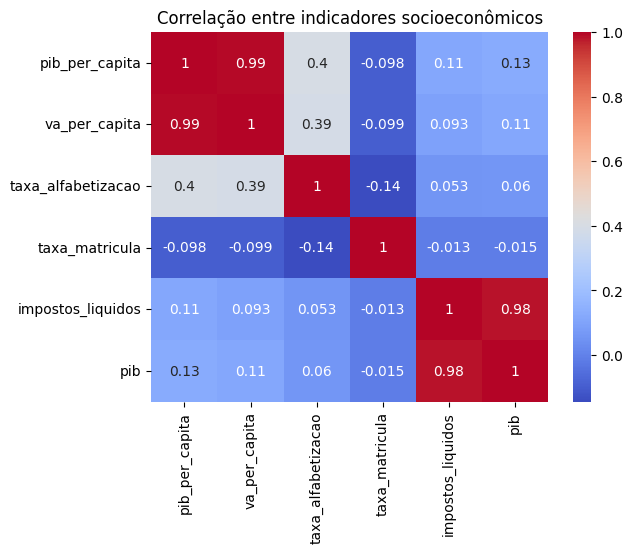

In [27]:
# Calcular a matriz de correlação entre os indicadores selecionados
corr_matrix = df[['pib_per_capita','va_per_capita','taxa_alfabetizacao','taxa_matricula', 'impostos_liquidos', 'pib']].corr()
print("Matriz de correlação:\n", corr_matrix)  # Exibir a matriz no console

# Criar um heatmap da matriz de correlação usando Seaborn
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')  # Heatmap com valores anotados e cores 'coolwarm'
plt.title('Correlação entre indicadores socioeconômicos')  # Título do gráfico

# Salvar a figura em alta resolução no diretório especificado
# plt.savefig(os.path.join(f"{REPORTS_DIRECTORY_PATH}/", 'matriz_correlacao_lavras.png'), dpi=300, bbox_inches='tight')

plt.show()   # Exibir o gráfico
plt.close()  # Fechar a figura para liberar memória


## Modeo de Machine Learning - Regressão Linear

### Pré-Processamento e Treinamento

In [30]:
features = ['pib','pib_per_capita','impostos_liquidos',
            'taxa_alfabetizacao','taxa_matricula','populacao_total']
target = 'pib_per_capita'

X = df[features]
y = df[target]

print(X)

# Padronizar variáveis
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Treinar modelo
model = LinearRegression()
model.fit(X_scaled, y)

# Predizer PIB per capita de Lavras
lavras_scaled = scaler.transform(lavras[features])
pred_pib_lavras = model.predict(lavras_scaled)[0]

print(f"PIB per capita real de Lavras: {lavras['pib_per_capita'].values[0]:.2f} milhões por pessoa")
print(f"PIB per capita previsto pelo modelo: {pred_pib_lavras:.2f} milhões por pessoa")

# Avaliação do modelo
y_pred = model.predict(X_scaled)
r2 = r2_score(y, y_pred)
print(f"R² do modelo: {r2:.2f}")

                pib  pib_per_capita  impostos_liquidos  taxa_alfabetizacao  \
0         478217000    20251.418650           23202000            0.654188   
1         485374000    20749.572503           25125000            0.660397   
2         498980000    21538.395131           28255000            0.666811   
3         495775000    21607.103944           29351000            0.673262   
4         570242000    25089.845125           35109000            0.679690   
...             ...             ...                ...                 ...   
27845  235540045000    81495.429074        29145619000            0.768060   
27846  244722249000    83492.831767        29120462000            0.757360   
27847  254817205000    85661.393759        28692287000            0.746248   
27848  273613711000    90742.750230        30686608000            0.736209   
27849  265847334000    87016.159932        25466228000            0.726598   

       taxa_matricula  populacao_total  
0            0.263403 

KeyError: "['pib', 'impostos_liquidos'] not in index"

### Predição

### Avaliação do Modelo

C:\Users\Maurício\AppData\Local\Temp\ipykernel_15264\2164862718.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x='impacto', y='agente', palette='viridis')


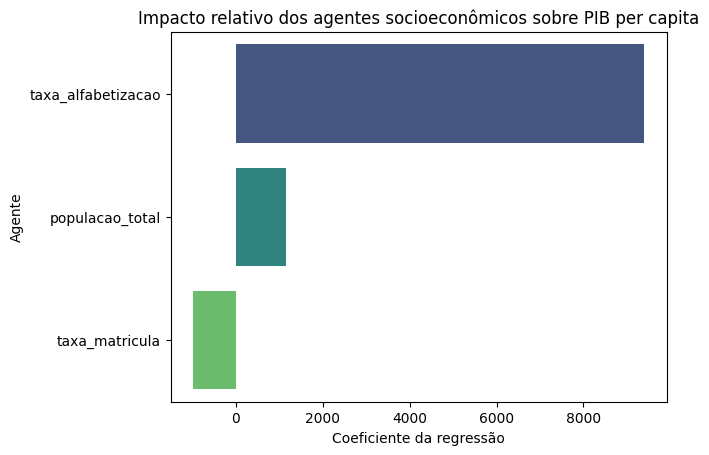

In [24]:
# Criar um DataFrame com os coeficientes do modelo para cada variável (agente)
coef_df = pd.DataFrame({
    'agente': features,       # Nomes das variáveis independentes
    'impacto': model.coef_    # Coeficientes da regressão linear
})

# Ordenar o DataFrame pelos coeficientes em ordem decrescente
coef_df = coef_df.sort_values('impacto', ascending=False)

# Criar um gráfico de barras mostrando o impacto relativo de cada agente
sns.barplot(data=coef_df, x='impacto', y='agente', palette='viridis')
plt.title('Impacto relativo dos agentes socioeconômicos sobre PIB per capita')  # Título do gráfico
plt.xlabel('Coeficiente da regressão')  # Label do eixo X
plt.ylabel('Agente')                     # Label do eixo Y

# Salvar a figura em alta resolução
# plt.savefig(os.path.join(f"{REPORTS_DIRECTORY_PATH}/", 'impacto_rel_agentes_socioeconomicos_pib_per_capita.png'), dpi=300, bbox_inches='tight')

plt.show()   # Exibir o gráfico
plt.close()  # Fechar a figura para liberar memória
